In [2]:
import re
import time
import csv

import nibabel as nib
import numpy as np
import colorcet as cc
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib

from nilearn.masking import apply_mask, unmask
from nilearn.image import math_img, high_variance_confounds

# Reportlab for pdf 

from reportlab.pdfbase import pdfmetrics
from reportlab.lib.utils import ImageReader
from reportlab.pdfgen import canvas

In [3]:
# Reportlab params for reports

MontSerratBold = pdfmetrics.EmbeddedType1Face('../../../utils/fonts/montserrat/Montserrat-Bold.afm', '../../../utils/fonts/montserrat/Montserrat-Bold.pfb')
MontSerratLight = pdfmetrics.EmbeddedType1Face('../../../utils/fonts/montserrat/Montserrat-Light.afm', '../../../utils/fonts/montserrat/Montserrat-Light.pfb')

# Montserrat Bold

pdfmetrics.registerTypeFace(MontSerratBold)
montserrat_bold_name = 'Montserrat-Bold'

montserrat_bold_font = pdfmetrics.Font('Montserrat-Bold',
                           montserrat_bold_name,
                           'WinAnsiEncoding')

pdfmetrics.registerFont(montserrat_bold_font)

# Montserrat Light

pdfmetrics.registerTypeFace(MontSerratLight)
montserrat_light_name = 'Montserrat-Light'

montserrat_light_font = pdfmetrics.Font('Montserrat-Light',
                           montserrat_light_name,
                           'WinAnsiEncoding')

pdfmetrics.registerFont(montserrat_light_font)

# Helper functions

In [4]:
def write_tsv(data, save_name):
    
    with open(save_name, 'w') as f:
        
        csv_writer = csv.writer(f)
        
        for x in data:
            
            csv_writer.writerow([x])
            
    return

# Parameters

In [5]:
# global parameters

mace_th = 3
t_r = 2.4
nb_poses = 4

# data

root_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/rawdata/')

root_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*pose-1.*proc-choppedSWregisteredSKSTR.*.nii.gz$', x.name)])

print(f'We found {len(root_dir)} files')

mask_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/pose_templates/')

mask_dir = sorted([x for x in mask_root.iterdir() if x.is_file() and re.match(f'^.*AllenMask.*pose-(0|1|2|3).*.nii.gz$', x.name)])

print(f'We found {len(mask_dir)} mask')

mask_list = []

for mask_name in mask_dir:
    
    mask_list.append(nib.load(mask_name))
    
############################################################# OUTPUT
    
save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/sample_masks/mace')
save_dir.mkdir(exist_ok = True, parents = True)

save_dir_QC = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/QCs/')
save_dir_QC.mkdir(exist_ok = True, parents = True)

log_name = save_dir / 'log.txt'

We found 53 files
We found 4 mask


In [118]:
with open(log_name, 'w') as f:

    for file_name in tqdm(root_dir):

        ###### Gets file features
    
        subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
        session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
        pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
        pose_idx = int(pose_id[-1])
        if 'run' in file_name.name:
            run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
            title = f'{subject_name} - {session_name} - {pose_id} - {run_id}'
        else: 
            title = f'{subject_name} - {session_name} - {pose_id}'
        
        prefix = file_name.name.split('_pwd')[0]
        
        if 'run' in file_name.name:
            file_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*{run_id}.*pose.*.nii.gz$', x.name)])
        else:
            file_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*pose.*.nii.gz$', x.name)])
        
        f.write(f'{file_name.name}\n{title}\n\n')
    
        for pose_name in file_dir:
            f.write(f'{pose_name.name}\n')
    
        f.write('\n')
        
        pose_sample_mask = []
        gss = []
        
        ########################### Export pose wise sample mask
        
        for pose_name in file_dir:
        
            local_pose_id = 'pose-' + pose_name.name.split('pose-')[1].split('_')[0]
            
            img = nib.load(pose_name)
            [X,Y,Z,T] = img.shape
            mask_img = mask_list[pose_idx]
            
            gs = apply_mask(img, mask_img).mean(1)
            gss.append(gs[:,None])
            
            sample_mask = (gs>(gs.mean()+mace_th*gs.std())).astype(int)
            
            save_name = save_dir / subject_name / session_name / f'{prefix.replace('pose-1', local_pose_id)}_sampleMask.tsv'
            save_name.parent.mkdir(exist_ok = True, parents = True)
            
            write_tsv(sample_mask, save_name)
            
            pose_sample_mask.append(sample_mask)
        
            f.write(f'\t{local_pose_id}:\t{sample_mask.sum()}/{len(sample_mask)} = {100*sample_mask.sum()/len(sample_mask):.2f}%\n')
    
        # Generates global output
    
        gs = np.concatenate(gss,1).mean(1)
        sample_mask = (np.array(pose_sample_mask).sum(axis = 0)>0).astype(int)
    
        ########################### Export global sample_mask
        
        if len(pose_sample_mask) == nb_poses:
            
            suffix = (prefix.split('pose')[0] + 'pose-vol_proc' + prefix.split('proc')[1]).split('pwd')[0]
            
            save_name = save_dir / subject_name / session_name / f'{suffix}_sampleMask.tsv'
            save_name.parent.mkdir(exist_ok = True, parents = True)
            save_name.parent.mkdir(exist_ok = True, parents = True)
            
            write_tsv(sample_mask, save_name)
        
            f.write(f'\n\tTotal:{100*sample_mask.sum()/len(sample_mask):.2f}%\n\n')
        
        ########################### Display QCs
        
        fig, ax = plt.subplots(2,1,figsize = (10,5), dpi = 200, facecolor = 'k', sharex = True)
        
        ax[0].set(facecolor = 'k')
        
        for y in np.arange(np.array(pose_sample_mask).shape[0])[1:]:
        
            ax[0].axhline(y-0.5, c = (0.8,0.8,0.8), ls = ':', lw = 0.5)
        
        ax[0].imshow(np.array(pose_sample_mask), aspect = 'auto', cmap = 'Greys_r', interpolation = 'none')
        ax[0].set_yticks(np.arange(np.array(pose_sample_mask).shape[0]), [f'pose-{x}' for x in np.arange(np.array(pose_sample_mask).shape[0])], c = 'w')
        
        ax[1].set(facecolor = 'k')
        ax[1].plot(np.arange(T), gs, c = 'C1' , lw = 0.5)
        ax[1].set_ylabel('GS (arb.u.)', c = 'w')
        ax[1].set_xlabel('Time (s)', c = 'w')
        ax[1].set_xticks(np.linspace(0, T, 4), [f'{x*t_r:.0f}' for x in np.linspace(0, T, 4)], c = 'w')
    
        if np.argwhere(sample_mask).shape[0] == 1:

            idx = np.argwhere(sample_mask)[0,0]
            plt.axvspan(idx-0.5, idx+0.5, facecolor = 'r', alpha = 0.3, edgecolor = None)
    
        else:
            
            for idx in np.argwhere(sample_mask).squeeze():
            
                plt.axvspan(idx-0.5, idx+0.5, facecolor = 'r', alpha = 0.3, edgecolor = None)            
            
            
        plt.suptitle(f'{title} - removed: {sample_mask.sum()}/{len(sample_mask)} = {100*sample_mask.sum()/len(sample_mask):.2f}%', c = 'w')
        
        save_name = save_dir_QC / subject_name / session_name / f'{prefix.replace('pose-1', 'pose-vol')}_sampleMask.png'
        save_name.parent.mkdir(parents = True, exist_ok = True)
        plt.savefig(save_name)
        
        plt.close('all')

100%|████████████████████████████████| 53/53 [06:37<00:00,  7.51s/it]


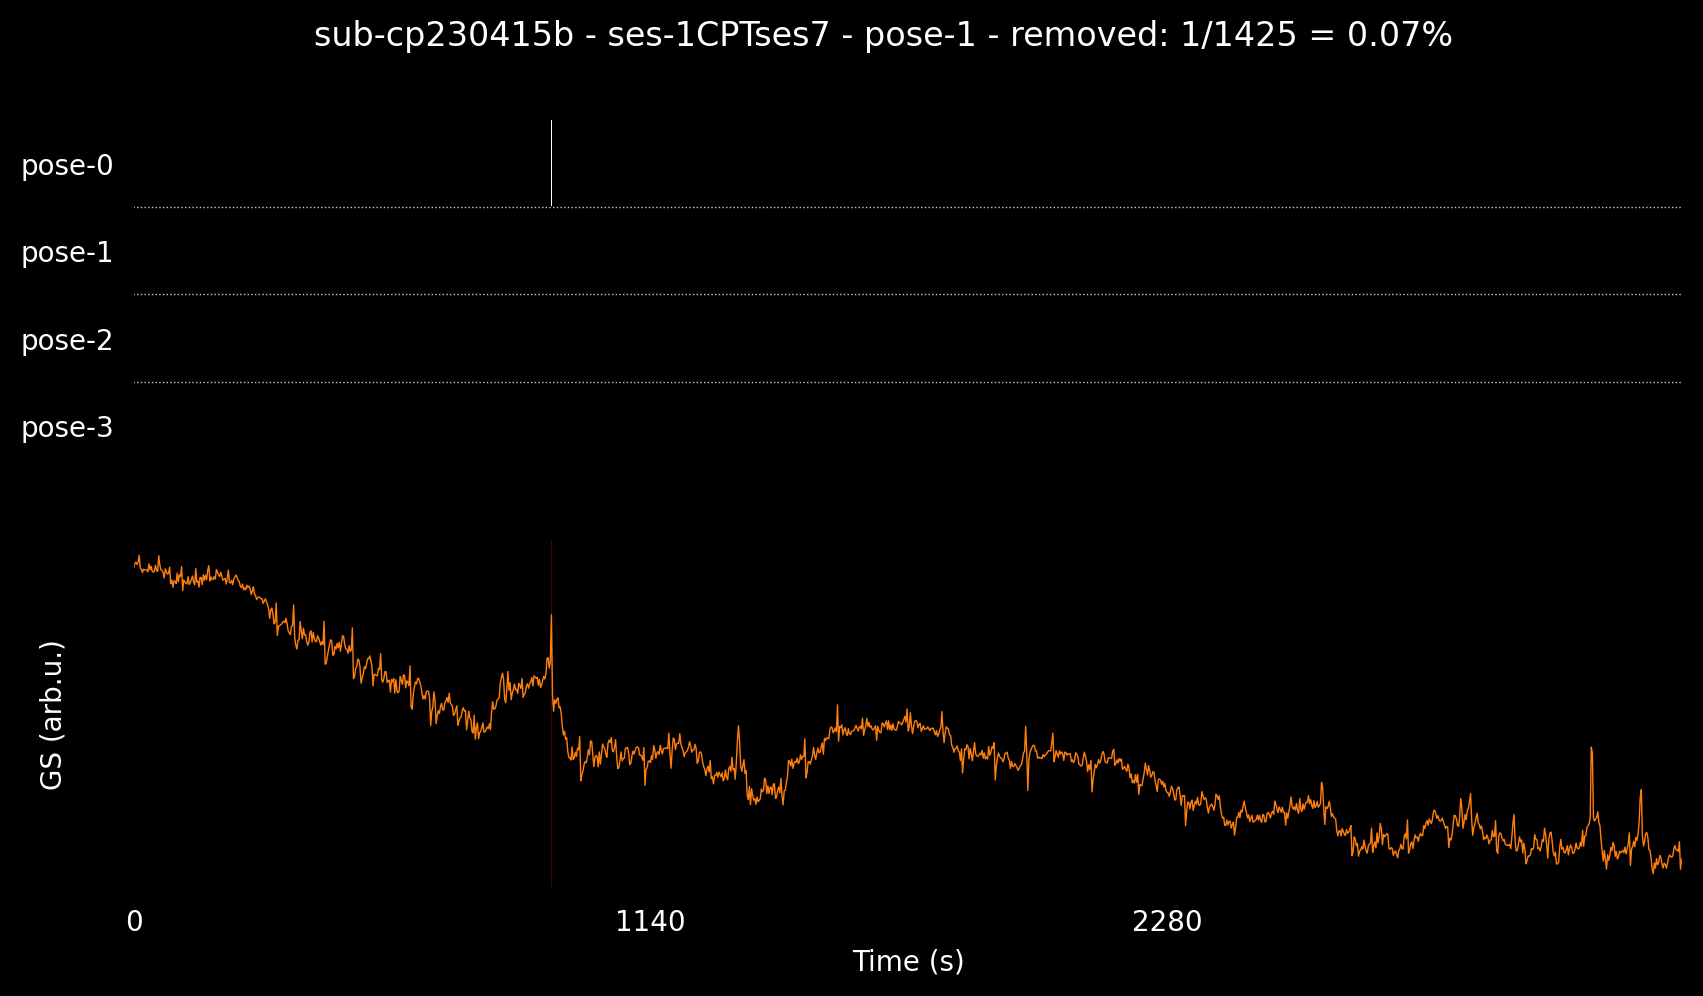

In [114]:
with open(log_name, 'w') as f:

    file_name = root_dir[24]
    
    ###### Gets file features
    
    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
    pose_idx = int(pose_id[-1])
    if 'run' in file_name.name:
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
        title = f'{subject_name} - {session_name} - {pose_id} - {run_id}'
    else: 
        title = f'{subject_name} - {session_name} - {pose_id}'
    
    prefix = file_name.name.split('_pwd')[0]
    
    if 'run' in file_name.name:
        file_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*{run_id}.*pose.*.nii.gz$', x.name)])
    else:
        file_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*pose.*.nii.gz$', x.name)])
    
    f.write(f'{file_name.name}\n{title}\n\n')

    for pose_name in file_dir:
        f.write(f'{pose_name.name}\n')

    f.write('\n')
    
    pose_sample_mask = []
    gss = []
    
    ########################### Export pose wise sample mask
    
    for pose_name in file_dir:
    
        local_pose_id = 'pose-' + pose_name.name.split('pose-')[1].split('_')[0]
        
        img = nib.load(pose_name)
        [X,Y,Z,T] = img.shape
        mask_img = mask_list[pose_idx]
        
        gs = apply_mask(img, mask_img).mean(1)
        gss.append(gs[:,None])
        
        sample_mask = (gs>(gs.mean()+mace_th*gs.std())).astype(int)
        
        save_name = save_dir / subject_name / session_name / f'{prefix.replace('pose-1', local_pose_id)}_sampleMask.tsv'
        save_name.parent.mkdir(exist_ok = True, parents = True)
        
        write_tsv(sample_mask, save_name)
        
        pose_sample_mask.append(sample_mask)
    
        f.write(f'\t{local_pose_id}:\t{sample_mask.sum()}/{len(sample_mask)} = {100*sample_mask.sum()/len(sample_mask):.2f}%\n')

    # Generates global output

    gs = np.concatenate(gss,1).mean(1)
    sample_mask = (np.array(pose_sample_mask).sum(axis = 0)>0).astype(int)

    ########################### Export global sample_mask
    
    if len(pose_sample_mask) == nb_poses:
        
        suffix = (prefix.split('pose')[0] + 'pose-vol_proc' + prefix.split('proc')[1]).split('pwd')[0]
        
        save_name = save_dir / subject_name / session_name / f'{suffix}_sampleMask.tsv'
        save_name.parent.mkdir(exist_ok = True, parents = True)
        save_name.parent.mkdir(exist_ok = True, parents = True)
        
        write_tsv(sample_mask, save_name)
    
        f.write(f'\n\tTotal:{100*sample_mask.sum()/len(sample_mask):.2f}%\n\n')
    
    ########################### Display QCs
    
    fig, ax = plt.subplots(2,1,figsize = (10,5), dpi = 200, facecolor = 'k', sharex = True)
    
    ax[0].set(facecolor = 'k')
    
    for y in np.arange(np.array(pose_sample_mask).shape[0])[1:]:
    
        ax[0].axhline(y-0.5, c = (0.8,0.8,0.8), ls = ':', lw = 0.5)
    
    ax[0].imshow(np.array(pose_sample_mask), aspect = 'auto', cmap = 'Greys_r', interpolation = 'none')
    ax[0].set_yticks(np.arange(np.array(pose_sample_mask).shape[0]), [f'pose-{x}' for x in np.arange(np.array(pose_sample_mask).shape[0])], c = 'w')
    
    ax[1].set(facecolor = 'k')
    ax[1].plot(np.arange(T), gs, c = 'C1' , lw = 0.5)
    ax[1].set_ylabel('GS (arb.u.)', c = 'w')
    ax[1].set_xlabel('Time (s)', c = 'w')
    ax[1].set_xticks(np.linspace(0, T, 4), [f'{x*t_r:.0f}' for x in np.linspace(0, T, 4)], c = 'w')

    if np.argwhere(sample_mask).shape[0]>1:
        
        for idx in np.argwhere(sample_mask).squeeze():
        
            plt.axvspan(idx-0.5, idx+0.5, facecolor = 'r', alpha = 0.3, edgecolor = None)

    else:
        idx = np.argwhere(sample_mask)[0,0]
        plt.axvspan(idx-0.5, idx+0.5, facecolor = 'r', alpha = 0.3, edgecolor = None)
        
    plt.suptitle(f'{title} - removed: {sample_mask.sum()}/{len(sample_mask)} = {100*sample_mask.sum()/len(sample_mask):.2f}%', c = 'w')
    
    save_name = save_dir_QC / subject_name / session_name / f'{prefix.replace('pose-1', 'pose-vol')}_sampleMask.png'
    save_name.parent.mkdir(parents = True, exist_ok = True)
    plt.savefig(save_name)
    
    # plt.close('all')

In [113]:
np.argwhere(sample_mask).shape

(34, 1)

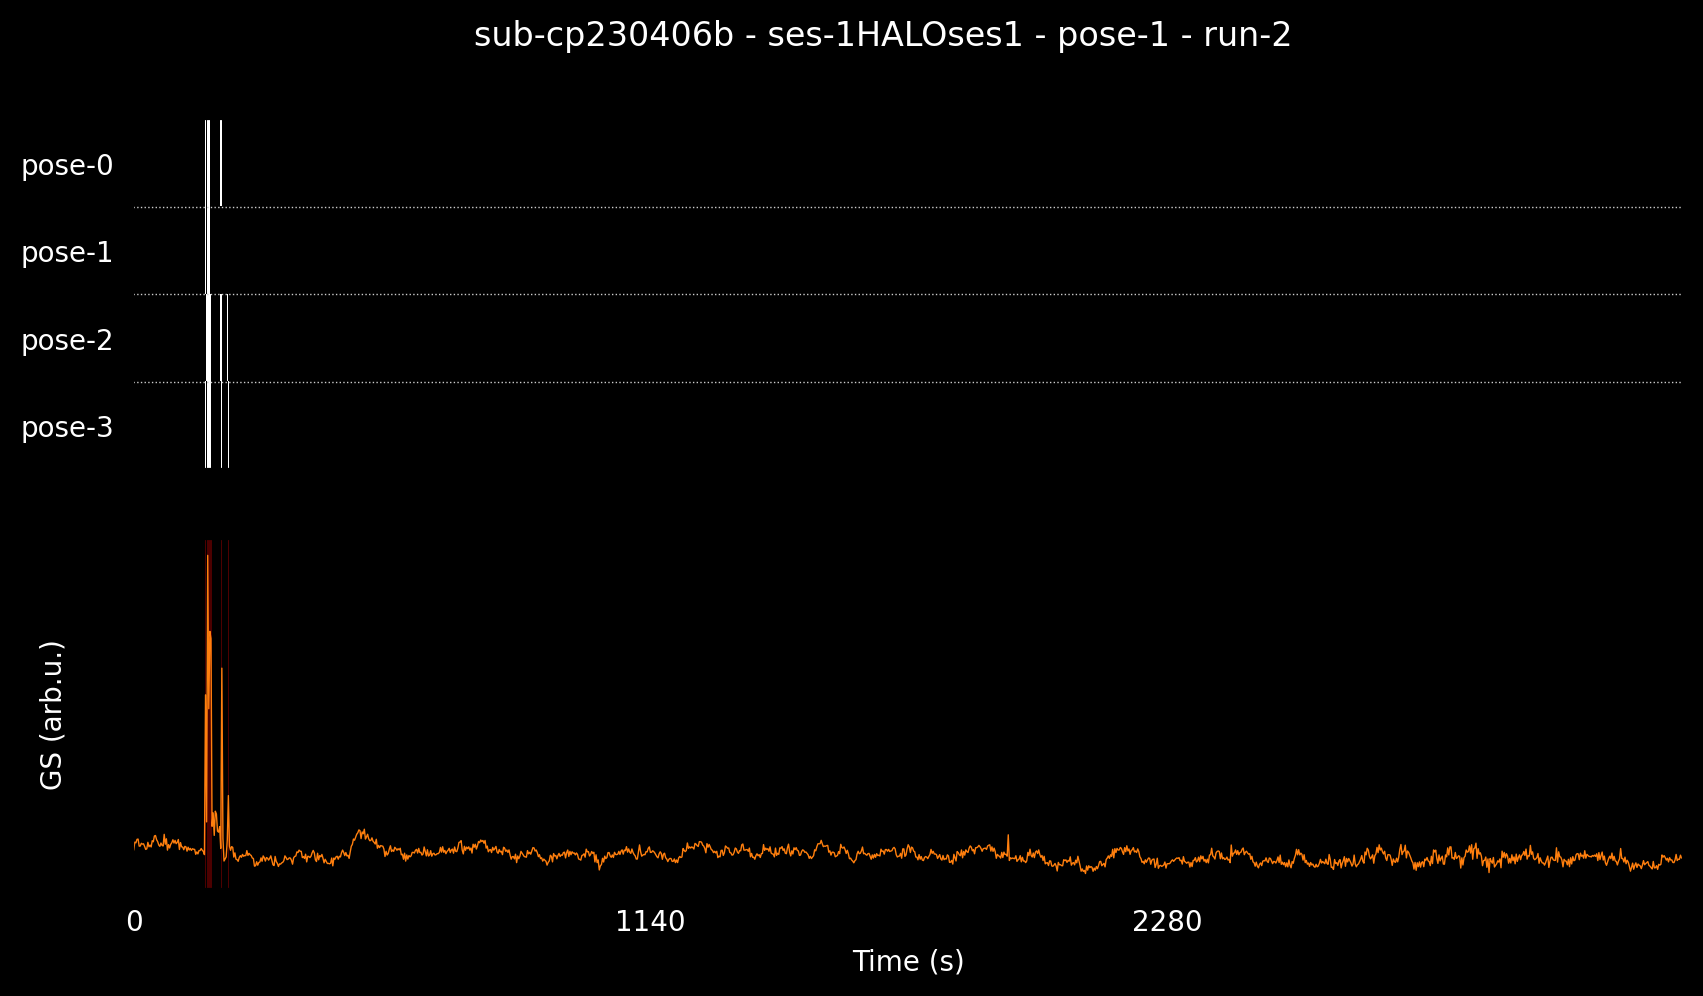

'sub-cp230406b_ses-1HALOses1_task-rest_acq-3Dfus_probe-linear_run-2_pose-vol_proc-choppedSWregisteredSKSTR'

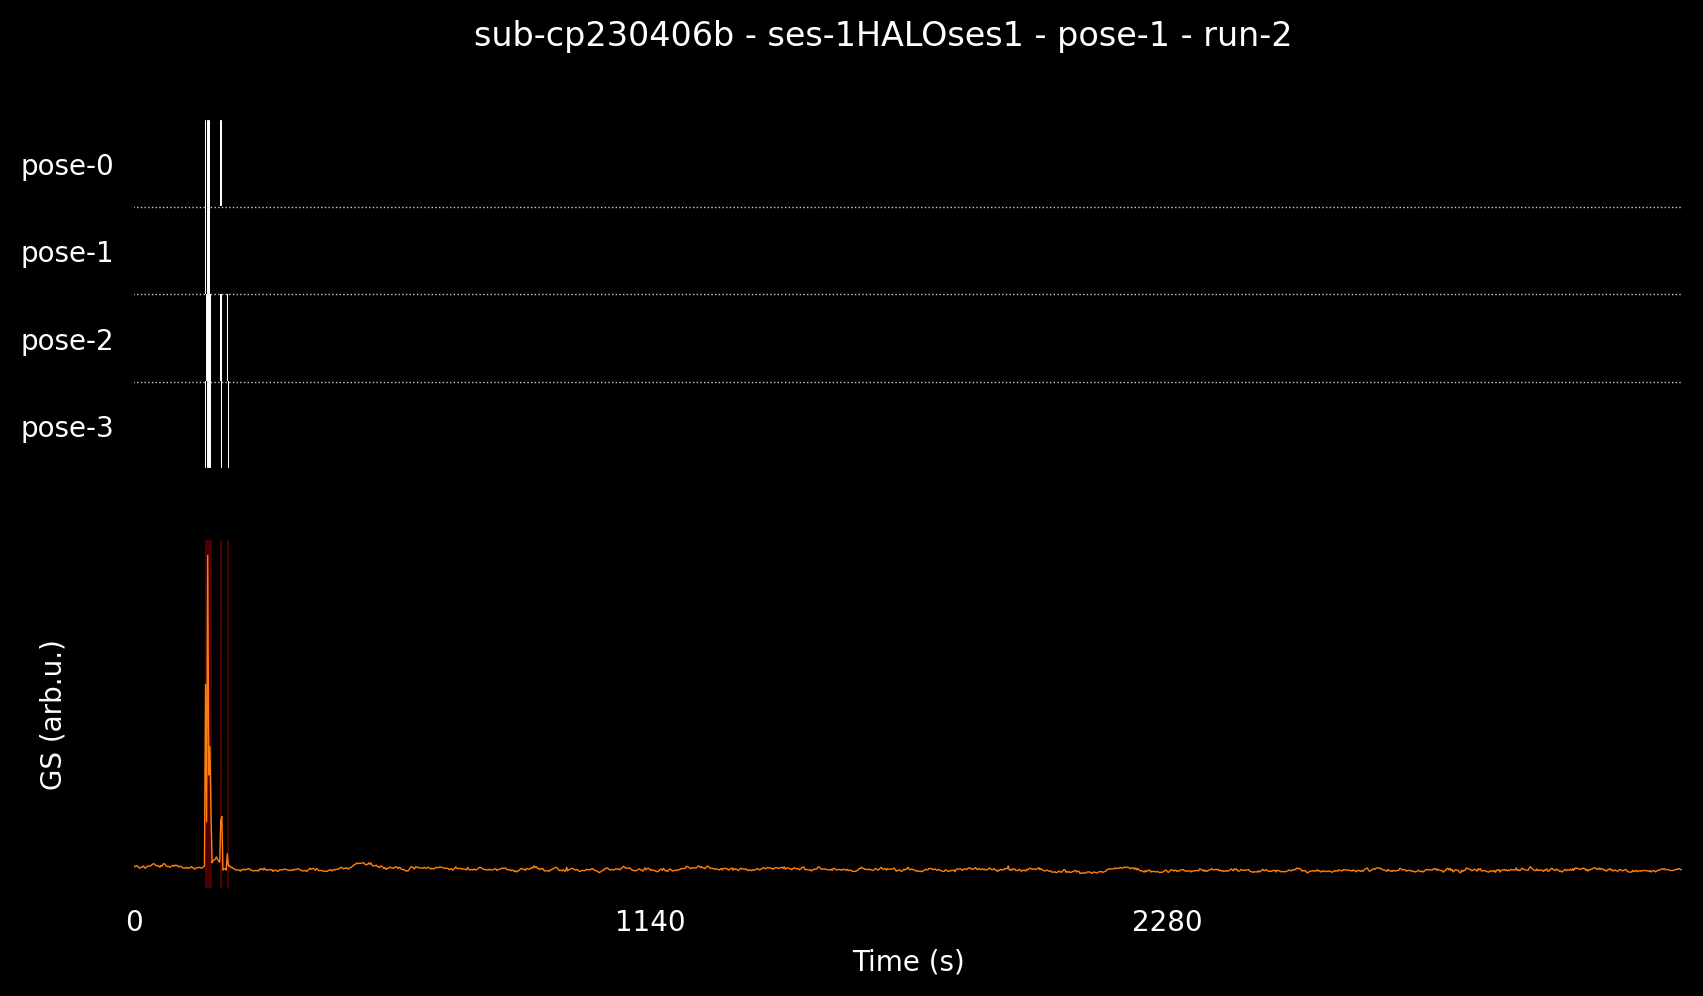